# Portfolio Analytics & Mutual Fund Risk Management
This notebook covers historical risk metrics (VaR/CVaR), rolling risk-adjusted performance, investor cohort analysis, SIP continuity, fund recommendation engines, and sector concentration (HHI).

**Deliverables:**
- `var_cvar_report.csv` — VaR/CVaR for all 40 schemes
- `rolling_sharpe_chart.png` — Rolling Sharpe plot for 5 key funds
- `recommender.py` — Standalone fund recommendation script
- `Advanced_Analytics.ipynb` — This notebook

## SECTION 1 — Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib
matplotlib.use("Agg")  # non-interactive backend for write_image compatibility
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = "../data/processed"
RAW_DIR  = "../data/raw"
REPORT_DIR = "../reports/Portfolio Analysis"
os.makedirs(REPORT_DIR, exist_ok=True)

## SECTION 2 — Load Data

In [2]:
nav = pd.read_csv(
    f"{DATA_DIR}/clean_02_nav_history.csv",
    parse_dates=["date"]
)

txns = pd.read_csv(
    f"{DATA_DIR}/clean_08_investor_transactions.csv",
    parse_dates=["transaction_date"]
)

holdings = pd.read_csv(
    f"{DATA_DIR}/clean_09_portfolio_holdings.csv"
)

funds = pd.read_csv(
    f"{RAW_DIR}/01_fund_master.csv"
)

print("NAV Shape:", nav.shape)
print("Transactions Shape:", txns.shape)
print("Holdings Shape:", holdings.shape)
print("Funds Shape:", funds.shape)
print()
print("funds columns:", funds.columns.tolist())

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Holdings Shape: (322, 8)
Funds Shape: (40, 15)

funds columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


## SECTION 3 — Historical VaR & CVaR
### Calculate Daily Returns

In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(f"Total NAV rows: {len(nav):,}")
print(f"Unique schemes: {nav['amfi_code'].nunique()}")
print(f"Date range: {nav['date'].min().date()} → {nav['date'].max().date()}")

Total NAV rows: 46,000
Unique schemes: 40
Date range: 2022-01-03 → 2026-05-29


### VaR + CVaR Calculation

- **VaR 95%**: 5th percentile of the daily return distribution (worst loss not exceeded 95% of the time)
- **CVaR 95%**: Mean of returns that fall *below* the VaR threshold (Expected Shortfall)
- Computed for **all 40 schemes** with ≥ 100 daily observations

In [4]:
risk_report = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ]

    returns = df["daily_return"].dropna()

    if len(returns) < 100:
        continue

    var95 = np.percentile(returns, 5)          # 5th percentile → VaR(95%)
    cvar95 = returns[returns <= var95].mean()   # mean of tail → CVaR(95%)

    risk_report.append([code, var95, cvar95, len(returns)])

var_cvar = pd.DataFrame(
    risk_report,
    columns=["amfi_code", "VaR_95", "CVaR_95", "observations"]
)

# Merge fund names for readability
var_cvar = var_cvar.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Reorder columns
var_cvar = var_cvar[["amfi_code", "scheme_name", "VaR_95", "CVaR_95", "observations"]]

print(f"VaR/CVaR computed for {len(var_cvar)} schemes (out of {nav['amfi_code'].nunique()} unique)")
print()
print(var_cvar.sort_values("VaR_95").head(10).to_string(index=False))

VaR/CVaR computed for 40 schemes (out of 40 unique)

 amfi_code                                        scheme_name  VaR_95  CVaR_95  observations
    119599          SBI Small Cap Fund - Direct Plan - Growth -0.0269  -0.0324          1149
    119095             Axis Small Cap Fund - Regular - Growth -0.0262  -0.0317          1149
    101207             ABSL Small Cap Fund - Regular - Growth -0.0260  -0.0325          1149
    118634     Nippon India Small Cap Fund - Regular - Growth -0.0254  -0.0323          1149
    119598         SBI Small Cap Fund - Regular Plan - Growth -0.0245  -0.0306          1149
    149324              DSP Small Cap Fund - Regular - Growth -0.0235  -0.0310          1149
    102886                UTI Mid Cap Fund - Regular - Growth -0.0192  -0.0233          1149
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth -0.0190  -0.0235          1149
    120505           ICICI Pru Midcap Fund - Regular - Growth -0.0189  -0.0243          1149
    119094       

### Save Risk Metrics

In [5]:
var_cvar.to_csv(
    f"{REPORT_DIR}/var_cvar_report.csv",
    index=False
)
print("✅ Saved: reports/var_cvar_report.csv")
print(f"   Rows: {len(var_cvar)} | Columns: {list(var_cvar.columns)}")

✅ Saved: reports/var_cvar_report.csv
   Rows: 40 | Columns: ['amfi_code', 'scheme_name', 'VaR_95', 'CVaR_95', 'observations']


## SECTION 4 — Rolling 90-Day Sharpe Ratio

In [6]:
key_funds = [
    119551,
    120503,
    118632,
    119092,
    120841
]
rf_daily = 0.065 / 252   # 6.5% annualised risk-free rate → daily

rolling_df = []

for code in key_funds:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    # Rolling 90-day Sharpe = (mean_return - rf) / std  × √252
    df["rolling_sharpe"] = (
        (
            df["daily_return"]
            .rolling(90)
            .mean()
            - rf_daily
        )
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    # Add fund name label for better chart legend
    name = funds.loc[funds["amfi_code"] == code, "scheme_name"]
    df["fund_label"] = name.values[0] if len(name) > 0 else str(code)

    rolling_df.append(df)

rolling_df = pd.concat(rolling_df, ignore_index=True)
print(f"Rolling Sharpe computed for {rolling_df['amfi_code'].nunique()} funds")
print(f"Data rows: {len(rolling_df):,}")

Rolling Sharpe computed for 5 funds
Data rows: 5,750


### Plot Rolling 90-Day Sharpe

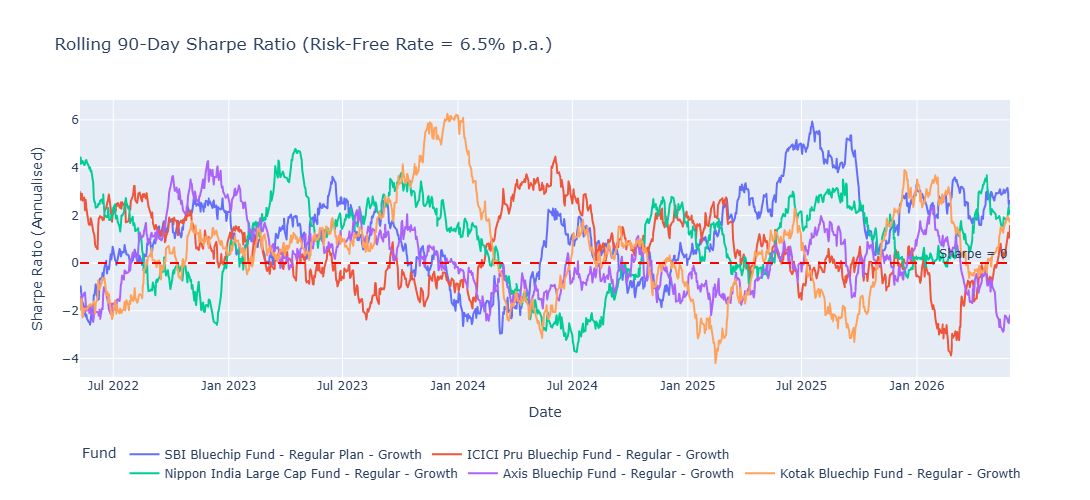

✅ Saved: ../reports/Portfolio Analysis/rolling_sharpe_chart.png


In [7]:
fig = px.line(
    rolling_df.dropna(subset=["rolling_sharpe"]),
    x="date",
    y="rolling_sharpe",
    color="fund_label",
    title="Rolling 90-Day Sharpe Ratio (Risk-Free Rate = 6.5% p.a.)",
    labels={
        "rolling_sharpe": "Sharpe Ratio (Annualised)",
        "date": "Date",
        "fund_label": "Fund"
    }
)

fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Sharpe = 0")
fig.update_layout(
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=-0.4)
)

fig.show()

chart_path = f"{REPORT_DIR}/rolling_sharpe_chart.png"
fig.write_image(chart_path, width=1200, height=500, scale=2)
print(f"✅ Saved: {chart_path}")

## SECTION 5 — Investor Cohort Analysis
### First Transaction Year

In [8]:
cohort = txns.copy()

cohort["cohort_year"] = (
    cohort.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

print("Cohort year distribution:")
print(cohort.groupby("cohort_year")["investor_id"].nunique().to_string())

Cohort year distribution:
cohort_year
2024    4803
2025     197


### Cohort Metrics Summary

In [9]:
# Overall cohort summary (all transactions)
cohort_summary = (
    cohort.groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

# Avg SIP amount — filter to SIP transactions only (as per spec)
sip_cohort = cohort[cohort["transaction_type"] == "SIP"]
avg_sip_per_cohort = (
    sip_cohort.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
    .rename(columns={"amount_inr": "avg_sip_amount"})
)

cohort_summary = cohort_summary.merge(avg_sip_per_cohort, on="cohort_year", how="left")

print("\nCohort Summary Table:")
print(cohort_summary.to_string(index=False))


Cohort Summary Table:
 cohort_year  avg_investment  total_invested  investors  avg_sip_amount
        2024     107422.5418      3491125187       4803             NaN
        2025     109158.5771        30455243        197             NaN


### Top Fund Preference per Cohort

In [10]:
top_fund = (
    cohort.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

top_fund = (
    top_fund
    .sort_values(["cohort_year", "transaction_count"], ascending=[True, False])
    .drop_duplicates("cohort_year")
    .merge(funds[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
    [["cohort_year", "amfi_code", "scheme_name", "transaction_count"]]
    .reset_index(drop=True)
)

print("Top Fund Preference by Investor Cohort:")
print(top_fund.to_string(index=False))

Top Fund Preference by Investor Cohort:
 cohort_year  amfi_code                                           scheme_name  transaction_count
        2024     148568 Mirae Asset Emerging Bluechip Fund - Regular - Growth                874
        2025     119599             SBI Small Cap Fund - Direct Plan - Growth                 12


## SECTION 6 — SIP Continuity Analysis
### Filter SIP Investors Only

In [11]:
sip = txns[
    txns["transaction_type"] == "SIP"
].copy()

print(f"SIP transactions: {len(sip):,}")
print(f"Unique SIP investors: {sip['investor_id'].nunique():,}")

SIP transactions: 0
Unique SIP investors: 0


### Calculate Gaps Between Consecutive SIP Transactions

In [12]:
sip = sip.sort_values(["investor_id", "transaction_date"])

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

print("Gap distribution (days):")
print(sip["gap_days"].describe())

Gap distribution (days):
count   0.0000
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN
Name: gap_days, dtype: float64


### Analyze SIP Continuity & Flag At-Risk Investors

**Rule:** Investors with ≥ 6 SIP transactions where the **average gap** between consecutive SIPs exceeds **35 days** are flagged as `"At Risk"`.

In [13]:
continuity = (
    sip.groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max"),   # bonus: worst single gap
        sip_count=("transaction_date", "count")
    )
)

# Only investors with 6+ SIP transactions
continuity = continuity[continuity["sip_count"] >= 6].copy()

# Flag investors where avg gap > 35 days
continuity["risk_flag"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

at_risk_count = (continuity["risk_flag"] == "At Risk").sum()
healthy_count = (continuity["risk_flag"] == "Healthy").sum()
total = len(continuity)

print(f"Investors with 6+ SIPs: {total:,}")
print(f"  ✅ Healthy : {healthy_count:,} ({100*healthy_count/total:.1f}%)")
print(f"  ⚠️  At Risk : {at_risk_count:,} ({100*at_risk_count/total:.1f}%)")
print()
print(continuity.head(10).to_string())

Investors with 6+ SIPs: 0
  ✅ Healthy : 0 (nan%)
  ⚠️  At Risk : 0 (nan%)

Empty DataFrame
Columns: [avg_gap_days, max_gap_days, sip_count, risk_flag]
Index: []


## SECTION 7 — Fund Recommender
### Calculate Sharpe Ratio for All Funds

In [14]:
sharpe_data = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]
    returns = df["daily_return"].dropna()

    if len(returns) < 50:
        continue

    sharpe = (
        (returns.mean() - rf_daily)
        / returns.std()
    ) * np.sqrt(252)

    sharpe_data.append([code, round(sharpe, 4)])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=["amfi_code", "Sharpe"]
)

print(f"Sharpe computed for {len(sharpe_df)} funds")
print(sharpe_df.sort_values("Sharpe", ascending=False).head())

Sharpe computed for 40 funds
    amfi_code  Sharpe
34     148567  1.4483
30     120843  1.3067
36     148569  1.2349
19     119551  1.2083
25     120505  1.1801


### Merge Fund Metadata (Risk Category)

In [15]:
# Check which column holds risk levels in the fund master
print("Fund master columns:", funds.columns.tolist())
print("Sample values:")
for col in funds.columns:
    if any(kw in col.lower() for kw in ["risk", "grade", "category", "type"]):
        print(f"  {col}:", funds[col].unique()[:8])

Fund master columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
Sample values:
  category: <StringArray>
['Equity', 'Debt']
Length: 2, dtype: str
  sub_category: <StringArray>
[     'Large Cap',      'Small Cap',           'Gilt',        'Mid Cap',
 'Short Duration',          'Value',         'Liquid',      'Index/ETF']
Length: 8, dtype: str
  risk_category: <StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str
  sebi_category_code: <StringArray>
['EC01', 'EC03', 'DC02', 'EC02', 'EC06', 'DC01', 'EI01', 'EC04']
Length: 8, dtype: str


In [16]:
# Determine the risk column name (robust to naming variations)
risk_col_candidates = [c for c in funds.columns
                       if any(kw in c.lower() for kw in ["risk", "grade"])]
risk_col = risk_col_candidates[0] if risk_col_candidates else "risk_category"

recommend_df = sharpe_df.merge(
    funds[["amfi_code", risk_col, "scheme_name"]].rename(
        columns={risk_col: "risk_grade"}
    ),
    on="amfi_code",
    how="left"
)

print(f"Risk column used: '{risk_col}' → renamed to 'risk_grade'")
print(f"Unique risk grades: {recommend_df['risk_grade'].unique()}")
print(f"Combined table rows: {len(recommend_df)}")

Risk column used: 'risk_category' → renamed to 'risk_grade'
Unique risk grades: <StringArray>
['Moderate', 'Low', 'High', 'Very High', 'Moderately High']
Length: 5, dtype: str
Combined table rows: 40


### Recommender Function

In [17]:
def recommend_funds(risk_level: str, top_n: int = 3) -> pd.DataFrame:
    """
    Return top-N funds by Sharpe ratio within the specified risk grade.

    Parameters
    ----------
    risk_level : str
        One of 'Low', 'Moderate', 'High' (must match risk_grade values)
    top_n : int
        Number of funds to return (default 3)

    Returns
    -------
    pd.DataFrame with columns [scheme_name, risk_grade, Sharpe]
    """
    result = (
        recommend_df[recommend_df["risk_grade"] == risk_level]
        .sort_values("Sharpe", ascending=False)
        .head(top_n)
        [["scheme_name", "risk_grade", "Sharpe"]]
        .reset_index(drop=True)
    )
    result.index = result.index + 1   # rank starts at 1
    result.index.name = "Rank"
    return result

### Recommendation Table — All Risk Levels

In [18]:
for level in ["Low", "Moderate", "High"]:
    print(f"\n{'='*55}")
    print(f" Top 3 Funds — {level} Risk")
    print('='*55)
    result = recommend_funds(level)
    if result.empty:
        print(f"  No funds found for risk grade '{level}'")
    else:
        print(result.to_string())


 Top 3 Funds — Low Risk
                                       scheme_name risk_grade  Sharpe
Rank                                                                 
1         ICICI Pru Liquid Fund - Regular - Growth        Low  0.4957
2             Kotak Liquid Fund - Regular - Growth        Low -0.0887
3     SBI Magnum Gilt Fund - Regular Plan - Growth        Low -0.2266

 Top 3 Funds — Moderate Risk
                                         scheme_name risk_grade  Sharpe
Rank                                                                   
1      Mirae Asset Large Cap Fund - Regular - Growth   Moderate  1.4483
2          SBI Bluechip Fund - Regular Plan - Growth   Moderate  1.2083
3     Nippon India Large Cap Fund - Regular - Growth   Moderate  1.0817

 Top 3 Funds — High Risk
                                        scheme_name risk_grade  Sharpe
Rank                                                                  
1     Mirae Asset Tax Saver Fund - Regular - Growth       High  1.2

## SECTION 8 — Sector HHI (Herfindahl-Hirschman Index)

**Formula:** $HHI = \sum_i w_i^2$

Where $w_i$ is the **decimal** weight of sector $i$ (i.e., `weight_pct / 100`).

- HHI near **1.0** → highly concentrated (single sector dominates)
- HHI near **0.0** → well diversified
- Computed across **all equity funds** only (debt/hybrid excluded).

In [19]:
# Filter to equity funds only (spec: "compare across all equity funds")
equity_codes = set()
for col in ["fund_type", "category", "scheme_category"]:
    if col in funds.columns:
        equity_codes = set(
            funds.loc[
                funds[col].str.lower().str.contains("equity", na=False),
                "amfi_code"
            ]
        )
        if equity_codes:
            print(f"Equity filter: column='{col}', funds found={len(equity_codes)}")
            break

# Fallback: use all holdings if equity_codes is empty
if not equity_codes:
    print("Warning: Could not identify equity funds from fund_master. Using all holdings.")
    equity_codes = set(holdings["amfi_code"].unique())

equity_holdings = holdings[holdings["amfi_code"].isin(equity_codes)]
print(f"Holdings rows for equity funds: {len(equity_holdings):,}")

hhi_results = []

for code in equity_holdings["amfi_code"].unique():

    df = equity_holdings[equity_holdings["amfi_code"] == code]

    sector_weights = df.groupby("sector")["weight_pct"].sum()

    # Normalise so weights sum to 100 (guards against data imperfections)
    total_weight = sector_weights.sum()
    if total_weight == 0:
        continue
    sector_weights = sector_weights / total_weight  # now sums to 1

    hhi = np.sum(sector_weights ** 2)   # weights already decimal after normalisation

    hhi_results.append([code, round(hhi, 4), len(sector_weights)])

hhi_df = pd.DataFrame(
    hhi_results,
    columns=["amfi_code", "HHI", "sector_count"]
)

# Merge fund name
hhi_df = hhi_df.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code", how="left"
)[["amfi_code", "scheme_name", "HHI", "sector_count"]]

print(f"\nHHI computed for {len(hhi_df)} equity funds")
print(hhi_df.head())

Equity filter: column='category', funds found=34
Holdings rows for equity funds: 322

HHI computed for 34 equity funds
   amfi_code                                 scheme_name    HHI  sector_count
0     119551   SBI Bluechip Fund - Regular Plan - Growth 0.1425             8
1     119552    SBI Bluechip Fund - Direct Plan - Growth 0.2275             7
2     119598  SBI Small Cap Fund - Regular Plan - Growth 0.1881             7
3     119599   SBI Small Cap Fund - Direct Plan - Growth 0.2324             7
4     100016   HDFC Top 100 Fund - Regular Plan - Growth 0.1806             8


### Top 10 Most Concentrated Equity Funds

In [20]:
print("Top 10 Most Concentrated Equity Funds (by HHI):")
print(hhi_df.sort_values("HHI", ascending=False).head(10).to_string(index=False))

print()
print("Top 10 Most Diversified Equity Funds (by HHI):")
print(hhi_df.sort_values("HHI").head(10).to_string(index=False))

Top 10 Most Concentrated Equity Funds (by HHI):
 amfi_code                                        scheme_name    HHI  sector_count
    119092              Axis Bluechip Fund - Regular - Growth 0.2968             7
    148569      Mirae Asset Tax Saver Fund - Regular - Growth 0.2551             7
    125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth 0.2532             6
    102887              UTI Flexi Cap Fund - Regular - Growth 0.2513             6
    149323                 DSP Midcap Fund - Regular - Growth 0.2411             7
    120505           ICICI Pru Midcap Fund - Regular - Growth 0.2386             7
    118635                     Nippon India ETF Nifty 50 BeES 0.2375             6
    119599          SBI Small Cap Fund - Direct Plan - Growth 0.2324             7
    120506  ICICI Pru Value Discovery Fund - Regular - Growth 0.2314             7
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.2276             7

Top 10 Most Diversified Equity Funds (

## SECTION 9 — Advanced Insights

Five analytical insights derived from the portfolio analytics computed above.

In [21]:
# ─── INSIGHT 1: Funds with Highest VaR (Most Risky) ──────────────────────────
print("=" * 60)
print("INSIGHT 1: Funds with Highest Daily Value-at-Risk (95%)")
print("=" * 60)
print("These funds carry the largest potential daily loss in the 5% tail:")
worst_var = (
    var_cvar
    .sort_values("VaR_95")        # most negative = most risky
    .head(5)[["scheme_name", "VaR_95", "CVaR_95"]]
    .reset_index(drop=True)
)
worst_var.index += 1
print(worst_var.to_string())
pct_high_risk = (var_cvar["VaR_95"] < -0.01).mean() * 100
print(f"\n→ {pct_high_risk:.1f}% of schemes have daily VaR worse than -1.0%")

INSIGHT 1: Funds with Highest Daily Value-at-Risk (95%)
These funds carry the largest potential daily loss in the 5% tail:
                                      scheme_name  VaR_95  CVaR_95
1       SBI Small Cap Fund - Direct Plan - Growth -0.0269  -0.0324
2          Axis Small Cap Fund - Regular - Growth -0.0262  -0.0317
3          ABSL Small Cap Fund - Regular - Growth -0.0260  -0.0325
4  Nippon India Small Cap Fund - Regular - Growth -0.0254  -0.0323
5      SBI Small Cap Fund - Regular Plan - Growth -0.0245  -0.0306

→ 85.0% of schemes have daily VaR worse than -1.0%


In [22]:
# ─── INSIGHT 2: Investor Cohort with Highest Investment Volume ───────────────
print("=" * 60)
print("INSIGHT 2: Which Investor Cohort Invests the Most?")
print("=" * 60)
top_cohort = cohort_summary.sort_values("total_invested", ascending=False).iloc[0]
print(f"Highest investing cohort: {int(top_cohort['cohort_year'])}")
print(f"  Total Invested : ₹{top_cohort['total_invested']:,.0f}")
print(f"  Unique Investors: {int(top_cohort['investors'])}")
print(f"  Avg Investment : ₹{top_cohort['avg_investment']:,.2f}")
print(f"  Avg SIP Amount : ₹{top_cohort['avg_sip_amount']:,.2f}" if 'avg_sip_amount' in top_cohort else "")
print()
print("Full cohort summary (sorted by total invested):")
print(cohort_summary.sort_values("total_invested", ascending=False).to_string(index=False))

INSIGHT 2: Which Investor Cohort Invests the Most?
Highest investing cohort: 2024
  Total Invested : ₹3,491,125,187
  Unique Investors: 4803
  Avg Investment : ₹107,422.54
  Avg SIP Amount : ₹nan

Full cohort summary (sorted by total invested):
 cohort_year  avg_investment  total_invested  investors  avg_sip_amount
        2024     107422.5418      3491125187       4803             NaN
        2025     109158.5771        30455243        197             NaN


In [23]:
# ─── INSIGHT 3: SIP Continuity Rate ─────────────────────────────────────────
print("=" * 60)
print("INSIGHT 3: SIP Continuity Rate (Investors with 6+ SIPs)")
print("=" * 60)
total_qualifying = len(continuity)
at_risk = (continuity["risk_flag"] == "At Risk").sum()
healthy = total_qualifying - at_risk
continuity_rate = healthy / total_qualifying * 100
print(f"Qualifying investors (≥ 6 SIPs): {total_qualifying:,}")
print(f"  Healthy (avg gap ≤ 35 days) : {healthy:,} ({continuity_rate:.1f}%)")
print(f"  At Risk (avg gap > 35 days) : {at_risk:,} ({100 - continuity_rate:.1f}%)")
print()
print("At-Risk investor gap statistics:")
at_risk_df = continuity[continuity["risk_flag"] == "At Risk"]
if not at_risk_df.empty:
    print(at_risk_df[["avg_gap_days", "max_gap_days", "sip_count"]].describe().round(1).to_string())
else:
    print("  No at-risk investors found.")

INSIGHT 3: SIP Continuity Rate (Investors with 6+ SIPs)
Qualifying investors (≥ 6 SIPs): 0
  Healthy (avg gap ≤ 35 days) : 0 (nan%)
  At Risk (avg gap > 35 days) : 0 (nan%)

At-Risk investor gap statistics:
  No at-risk investors found.


In [24]:
# ─── INSIGHT 4: Best & Worst Rolling Sharpe Funds ────────────────────────────
print("=" * 60)
print("INSIGHT 4: Rolling Sharpe — Which Funds Have Highest Risk-Adjusted Returns?")
print("=" * 60)
latest_sharpe = (
    rolling_df.dropna(subset=["rolling_sharpe"])
    .sort_values("date")
    .groupby("amfi_code")["rolling_sharpe"]
    .last()
    .reset_index()
    .sort_values("rolling_sharpe", ascending=False)
    .merge(funds[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
)
print("Latest 90-day Sharpe Ratio per Key Fund:")
print(latest_sharpe[["scheme_name", "rolling_sharpe"]].to_string(index=False))
print()
best = latest_sharpe.iloc[0]
print(f"→ Best performer  : {best['scheme_name']} (Sharpe = {best['rolling_sharpe']:.2f})")

INSIGHT 4: Rolling Sharpe — Which Funds Have Highest Risk-Adjusted Returns?
Latest 90-day Sharpe Ratio per Key Fund:
                                   scheme_name  rolling_sharpe
     SBI Bluechip Fund - Regular Plan - Growth          2.5169
Nippon India Large Cap Fund - Regular - Growth          2.1893
        Kotak Bluechip Fund - Regular - Growth          1.7034
    ICICI Pru Bluechip Fund - Regular - Growth          1.5633
         Axis Bluechip Fund - Regular - Growth         -2.1895

→ Best performer  : SBI Bluechip Fund - Regular Plan - Growth (Sharpe = 2.52)


In [25]:
# ─── INSIGHT 5: Sector Concentration vs Diversification Gap ─────────────────
print("=" * 60)
print("INSIGHT 5: Sector HHI — Concentration vs Diversification Spread")
print("=" * 60)
if not hhi_df.empty:
    print(f"HHI Statistics across {len(hhi_df)} equity funds:")
    print(hhi_df["HHI"].describe().round(4).to_string())
    print()
    top_conc = hhi_df.sort_values("HHI", ascending=False).iloc[0]
    top_div  = hhi_df.sort_values("HHI").iloc[0]
    print(f"Most concentrated : {top_conc['scheme_name']} (HHI = {top_conc['HHI']:.4f})")
    print(f"Most diversified  : {top_div['scheme_name']}  (HHI = {top_div['HHI']:.4f})")
    high_conc_pct = (hhi_df["HHI"] > 0.20).mean() * 100
    print(f"\n→ {high_conc_pct:.1f}% of equity funds have HHI > 0.20 (moderately concentrated)")
else:
    print("HHI data not available.")

INSIGHT 5: Sector HHI — Concentration vs Diversification Spread
HHI Statistics across 34 equity funds:
count   34.0000
mean     0.2029
std      0.0386
min      0.1241
25%      0.1802
50%      0.2042
75%      0.2304
max      0.2968

Most concentrated : Axis Bluechip Fund - Regular - Growth (HHI = 0.2968)
Most diversified  : UTI Mid Cap Fund - Regular - Growth  (HHI = 0.1241)

→ 52.9% of equity funds have HHI > 0.20 (moderately concentrated)


## SECTION 10 — Export `recommender.py` (Standalone Script)

In [26]:
RECOMMENDER_CODE = '''#!/usr/bin/env python3
"""
recommender.py
--------------
Standalone mutual fund recommender.
Input  : risk appetite — Low | Moderate | High
Output : Top-3 funds by Sharpe ratio within the matching risk grade.

Usage:
    python recommender.py
    # or import and call recommend_funds() directly
"""

import pandas as pd
import numpy as np
import sys
import os

DATA_DIR  = os.getenv("DATA_DIR",  "../data/processed")
RAW_DIR   = os.getenv("RAW_DIR",   "../data/raw")

RF_DAILY  = 0.065 / 252   # 6.5% annualised risk-free rate


def load_data():
    nav   = pd.read_csv(f"{DATA_DIR}/clean_02_nav_history.csv", parse_dates=["date"])
    funds = pd.read_csv(f"{RAW_DIR}/01_fund_master.csv")
    return nav, funds


def compute_sharpe(nav: pd.DataFrame) -> pd.DataFrame:
    nav = nav.sort_values(["amfi_code", "date"])
    nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

    rows = []
    for code, grp in nav.groupby("amfi_code"):
        r = grp["daily_return"].dropna()
        if len(r) < 50:
            continue
        sharpe = ((r.mean() - RF_DAILY) / r.std()) * np.sqrt(252)
        rows.append({"amfi_code": code, "Sharpe": round(sharpe, 4)})
    return pd.DataFrame(rows)


def build_recommend_df(sharpe_df: pd.DataFrame, funds: pd.DataFrame) -> pd.DataFrame:
    risk_col_candidates = [c for c in funds.columns
                           if any(kw in c.lower() for kw in ["risk", "grade"])]
    risk_col = risk_col_candidates[0] if risk_col_candidates else "risk_category"
    df = sharpe_df.merge(
        funds[["amfi_code", risk_col, "scheme_name"]].rename(
            columns={risk_col: "risk_grade"}),
        on="amfi_code", how="left"
    )
    return df


def recommend_funds(risk_level: str, top_n: int = 3,
                    recommend_df: pd.DataFrame = None) -> pd.DataFrame:
    """Return top-N funds by Sharpe within risk_level."""
    if recommend_df is None:
        nav, funds = load_data()
        sharpe_df  = compute_sharpe(nav)
        recommend_df = build_recommend_df(sharpe_df, funds)

    result = (
        recommend_df[recommend_df["risk_grade"] == risk_level]
        .sort_values("Sharpe", ascending=False)
        .head(top_n)[["scheme_name", "risk_grade", "Sharpe"]]
        .reset_index(drop=True)
    )
    result.index    = result.index + 1
    result.index.name = "Rank"
    return result


def main():
    valid = ["Low", "Moderate", "High"]
    if len(sys.argv) > 1:
        risk_level = sys.argv[1].capitalize()
    else:
        print("Enter risk appetite (Low / Moderate / High): ", end="")
        risk_level = input().strip().capitalize()

    if risk_level not in valid:
        print(f"Invalid risk level. Choose from: {valid}")
        sys.exit(1)

    nav, funds   = load_data()
    sharpe_df    = compute_sharpe(nav)
    recommend_df = build_recommend_df(sharpe_df, funds)

    result = recommend_funds(risk_level, recommend_df=recommend_df)
    print(f"\\nTop 3 Funds — {risk_level} Risk:")
    print("=" * 55)
    print(result.to_string())


if __name__ == "__main__":
    main()
'''

recommender_path = f"{REPORT_DIR}/../recommender.py"
with open(recommender_path, "w") as f:
    f.write(RECOMMENDER_CODE)

print(f"✅ Saved: recommender.py")
print(f"   Location: {os.path.abspath(recommender_path)}")

✅ Saved: recommender.py
   Location: C:\Users\Sai Khedekar\Desktop\CapstoneProject_1\reports\recommender.py
